# 101 - Learning a Temporal Pattern

**Section:** RNNs | **Prereqs:** `RNNs/RNN_class_in_PyTorch.ipynb` | **Next:** `RNNs/Sine_Wave_Extrapolation.ipynb`

The data is random magnitudes with strictly alternating signs: `+, -, +, -, ...`.
The *value* is unpredictable; the *sign* is completely determined by position. So
this cleanly separates what a sequence model can learn from what it cannot.

**Sign accuracy, not MSE, is the metric.** MSE will stay high forever because the
magnitudes are random noise. Sign accuracy goes to ~100%, showing the model
learned the only learnable structure. Choosing a metric that isolates the
learnable part is the real lesson here.

**The sliding-window setup.** A window of 9 values predicts the 10th, then the
window slides one step. This turns a single time series into many training
examples, and it is how nearly all sequence forecasting is framed.

**Read the note on the third plot.** Correlation between predictions and truth
across the whole series is high, but *within* either sign group it is near zero -
Simpson's paradox. The model captures the alternation and nothing about the
magnitudes, and an aggregate correlation hides that completely. Always check
whether a metric is being carried by group structure.

**The final test is the good one:** a sequence with the *opposite* phase. If the
model learned 'alternate', it transfers; if it memorised 'positive at even
indices', it fails.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchsummary

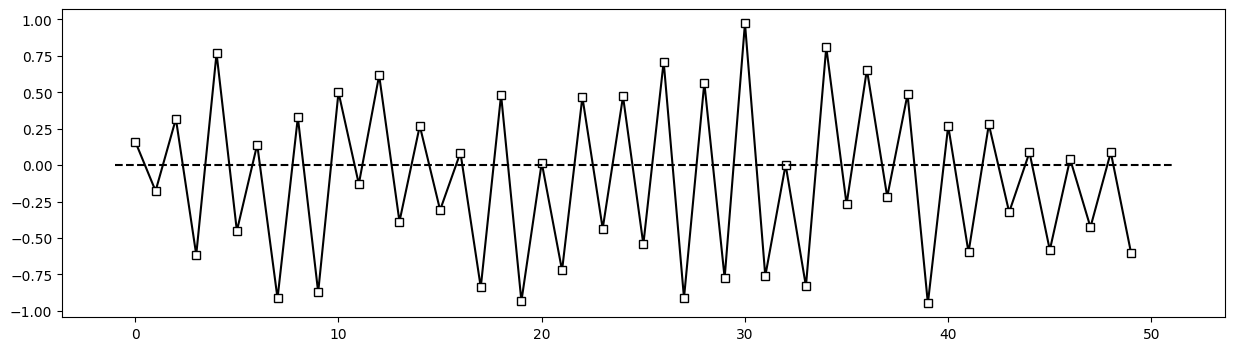

In [ ]:
# The data: random magnitudes with alternating signs.
# Magnitude is pure noise and cannot be predicted; the SIGN is fully determined
# by position. That separation is the design of the experiment.
N = 50

data = torch.zeros(N)

for i in range(N):
  data[i] = torch.rand(1) * (-1)**i

plt.figure(figsize=(15,4))
plt.plot(data, 'ks-', markerfacecolor='w')
plt.plot([-1,N+1] , [0,0] , "k--");

In [ ]:
# A minimal RNN + Linear head.
# Making the model now

class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers) -> None:
    super().__init__()

    self.rnn = nn.RNN(input_size,hidden_size,num_layers)

    self.out = nn.Linear(hidden_size,1)


  def forward(self, x):

    y,h = self.rnn(x)

    return self.out(y),h

In [ ]:
# The hyperparameters. seqlen=9 means the model sees 9 past values to predict
# the 10th - enough to make the alternation obvious.
input_size =  1 # "channels" of data
num_hidden =  5 # breadth of model (number of units in hidden layers)
num_layers =  1 # depth of model (number of "stacks" of hidden layers)
seqlen  =  9 # number of datapoints used for learning in each segment
batchsize  =  1 # Note: the training code is actually hard-coded to organize data into batchsize=1

In [ ]:
model = RNN(input_size,num_hidden, num_layers)
model

RNN(
  (rnn): RNN(1, 5)
  (out): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# Reshaping a slice into (seq_len, batch, features) - the shape nn.RNN wants.
x = data[:seqlen].view(seqlen,batchsize,input_size)
x.shape

torch.Size([9, 1, 1])

In [ ]:
y,h = model(x)
y.shape,h.shape

(torch.Size([9, 1, 1]), torch.Size([1, 1, 5]))

In [ ]:
# weight_ih (5,1) and weight_hh (5,5): tiny, because the pattern is simple.
for name,params in model.named_parameters():
  if 'weight' in name:
      print(f"Name {name} | Shape : {params.shape}")

Name rnn.weight_ih_l0 | Shape : torch.Size([5, 1])
Name rnn.weight_hh_l0 | Shape : torch.Size([5, 5])
Name out.weight | Shape : torch.Size([1, 5])


In [ ]:
epochs = 30

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
lossFunc = nn.MSELoss()

losses = []
signacc = []

In [ ]:
# Training with a SLIDING WINDOW: each iteration takes 9 consecutive values as
# input and the 10th as the target, then slides one step forward.
# That turns one time series into N-seqlen training examples, and it is how
# nearly all sequence forecasting is set up.
#
# loss is computed on yhat[-1] only - the prediction after the last time step.
# The earlier outputs exist but are not used here.
#
# Note the metric: SIGN accuracy, not MSE. MSE stays high forever because the
# magnitudes are random; sign accuracy isolates the part that is learnable.
# The hidden state h is reset each epoch but not carried between windows, so
# each window starts from a fresh (zero) memory.
for epoch in range(epochs):
    model.train()
    seqloss = []
    seqacc = []

    h = torch.zeros(num_layers, batchsize, num_hidden)

    for timei in range(N - seqlen):
        x = data[timei: timei + seqlen].view(seqlen, batchsize, input_size)
        y = data[timei + seqlen].view(1, 1)

        yhat, h = model(x)

        loss = lossFunc(yhat[-1], y)
        seqloss.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Fixed accuracy
        true_sign = np.sign(y.item())
        pred_sign = np.sign(yhat[-1].item())
        seqacc.append(100 * (pred_sign == true_sign))

    losses.append(np.mean(seqloss))
    signacc.append(np.mean(seqacc))

    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f'Epoch {epoch}/{epochs} | Loss: {losses[-1]:.4f} | Sign Acc: {signacc[-1]:.2f}%')

Epoch 0/30 | Loss: 0.3594 | Sign Acc: 48.78%
Epoch 5/30 | Loss: 0.2154 | Sign Acc: 85.37%
Epoch 10/30 | Loss: 0.0707 | Sign Acc: 100.00%
Epoch 15/30 | Loss: 0.0702 | Sign Acc: 100.00%
Epoch 20/30 | Loss: 0.0699 | Sign Acc: 100.00%
Epoch 25/30 | Loss: 0.0696 | Sign Acc: 100.00%
Epoch 29/30 | Loss: 0.0694 | Sign Acc: 100.00%


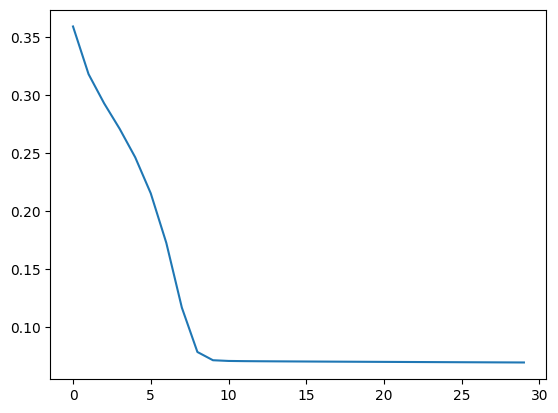

In [ ]:
# MSE. It will NOT go to zero - the magnitudes are unpredictable noise, and no
# model can do better than predicting their mean.
plt.plot(losses);

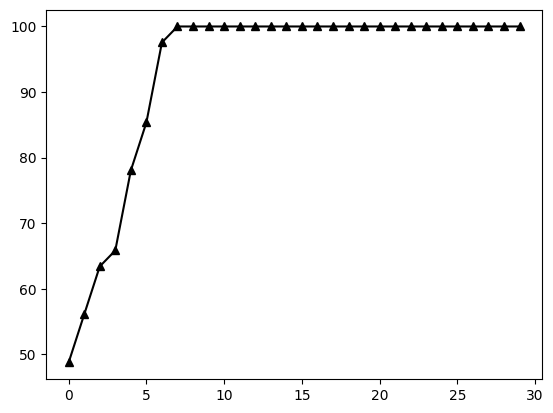

In [ ]:
# Sign accuracy, which should climb towards 100%. The right metric shows the
# learning that the wrong metric hides.
plt.plot(signacc, 'k^-');

/tmp/ipykernel_3515/734349654.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  yHat[timei+seqlen] = yy[-1]
/tmp/ipykernel_3515/734349654.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  h[timei+seqlen,:] = hh.detach()
/tmp/ipykernel_3515/734349654.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[1].plot(data-yHat,'k^')


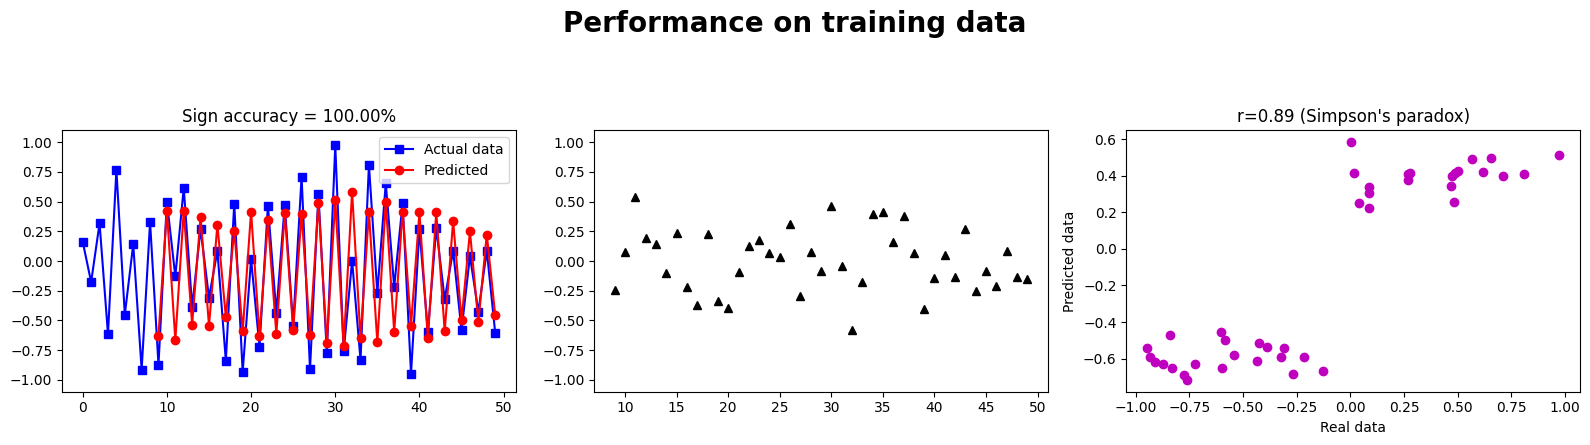

In [ ]:
# Three views of the fit.
# LEFT: predictions against the true series - the alternation should be tracked.
# MIDDLE: residuals, which stay large because the magnitudes are noise.
# RIGHT: predicted vs actual, with a high correlation - but note the title:
# SIMPSON'S PARADOX. The correlation comes almost entirely from the two sign
# groups being separated; WITHIN either group it is near zero.
# Always check whether an aggregate metric is being carried by group structure.
h = np.zeros((N,num_hidden))

# initialize predicted values
yHat = np.zeros(N)
yHat[:] = np.nan


# loop over time segments
for timei in range(N-seqlen):

  # grab a snippet of data
  X = data[timei:timei+seqlen].view(seqlen,1,1)

  # forward pass and loss
  yy,hh = model(X)
  yHat[timei+seqlen] = yy[-1]
  h[timei+seqlen,:] = hh.detach()


## compute sign-accuracy
truesign = np.sign(data.numpy())
predsign = np.sign(yHat)
signaccuracy = 100*np.mean(truesign[seqlen:]==predsign[seqlen:])


fig,ax = plt.subplots(1,3,figsize=(16,4))
ax[0].plot(data,'bs-',label='Actual data')
ax[0].plot(yHat,'ro-',label='Predicted')
ax[0].set_ylim([-1.1,1.1])
ax[0].set_title('Sign accuracy = %.2f%%' %signaccuracy)
ax[0].legend()

ax[1].plot(data-yHat,'k^')
ax[1].set_ylim([-1.1,1.1])

ax[2].plot(data[seqlen:],yHat[seqlen:],'mo')
ax[2].set_xlabel('Real data')
ax[2].set_ylabel('Predicted data')
r = np.corrcoef(data[seqlen:],yHat[seqlen:])
ax[2].set_title(f"r={r[0,1]:.2f} (Simpson's paradox)")

plt.suptitle('Performance on training data',fontweight='bold',fontsize=20,y=1.1)
plt.tight_layout()
plt.show()

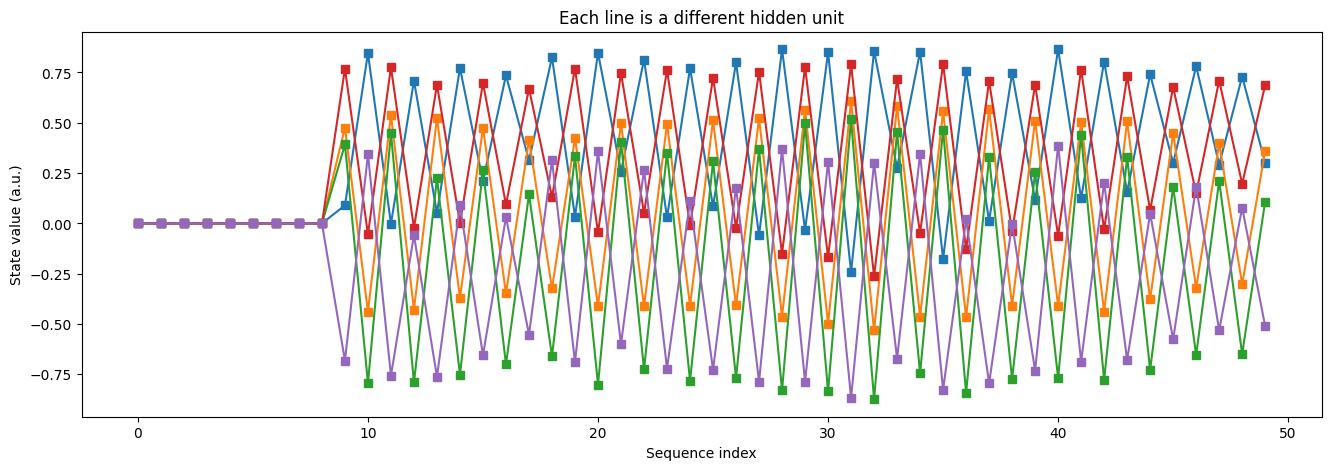

In [ ]:
# The hidden unit activations over the sequence. Each line is one of the 5 units.
# Expect visible oscillation at the alternation frequency - this is the memory
# doing its job, made visible.

# show the hidden "states" (units activations)
plt.figure(figsize=(16,5))

plt.plot(h,'s-')
plt.xlabel('Sequence index')
plt.ylabel('State value (a.u.)')
plt.title('Each line is a different hidden unit')
plt.show()


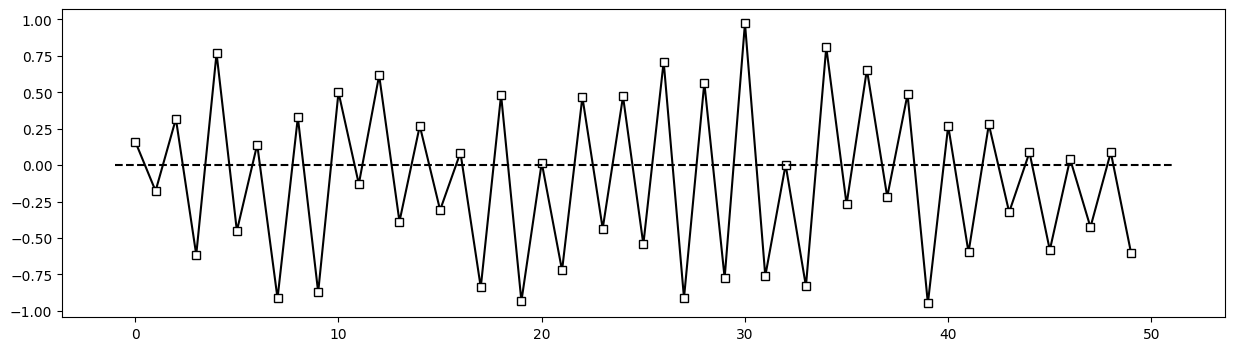

In [ ]:
# The real test: a sequence with the OPPOSITE phase (starting negative).
# If the model learned 'alternate', it transfers. If it memorised 'positive at
# even indices', it fails here.
N = 50

test_data = torch.zeros(N)

for i in range(N):
  test_data[i] = torch.rand(1) * (-1)**(i+1)

plt.figure(figsize=(15,4))
plt.plot(data, 'ks-', markerfacecolor='w')
plt.plot([-1,N+1] , [0,0] , "k--");

/tmp/ipykernel_3515/4047648256.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  h[timei+seqlen,:] = hh.detach()
/tmp/ipykernel_3515/4047648256.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[1].plot(test_data-yHat,'k^')


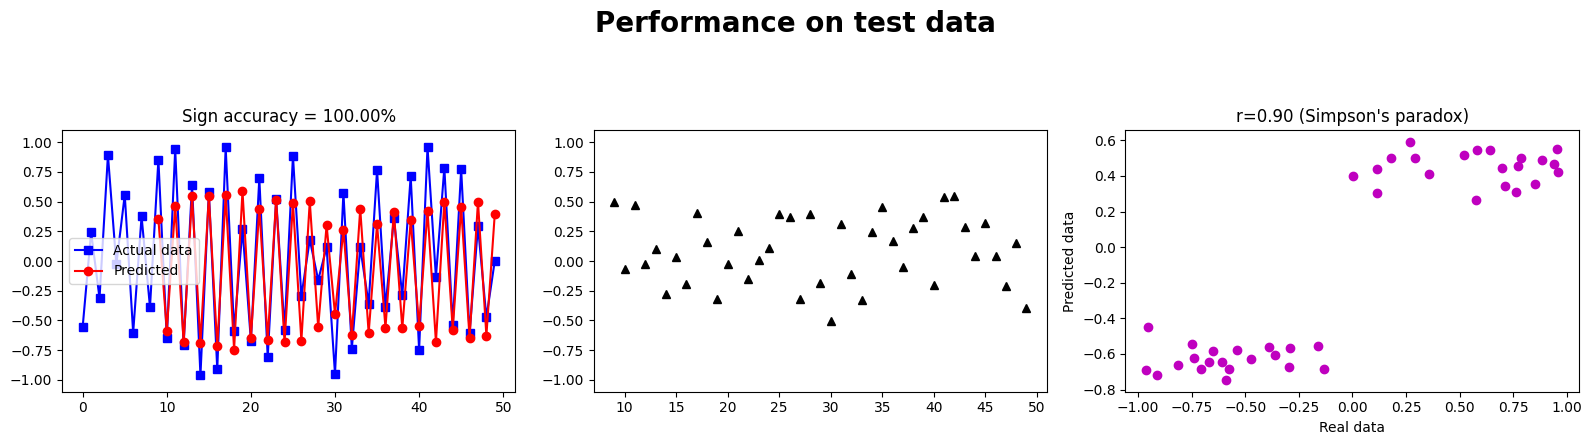

In [ ]:
# Sign accuracy on the phase-shifted sequence. High accuracy means the model
# learned the RELATIONSHIP between consecutive steps rather than absolute
# positions - which is exactly what a recurrent model is supposed to do.
h = np.zeros((N,num_hidden))

# initialize predicted values
yHat = np.zeros(N)
yHat[:] = np.nan


# loop over time segments
for timei in range(N-seqlen):

  # grab a snippet of data
  X = test_data[timei:timei+seqlen].view(seqlen,1,1)

  # forward pass and loss
  yy,hh = model(X)
  yHat[timei+seqlen] = yy[-1]
  h[timei+seqlen,:] = hh.detach()


## compute sign-accuracy
truesign = np.sign(test_data.numpy())
predsign = np.sign(yHat)
signaccuracy = 100*np.mean(truesign[seqlen:]==predsign[seqlen:])


fig,ax = plt.subplots(1,3,figsize=(16,4))
ax[0].plot(test_data,'bs-',label='Actual data')
ax[0].plot(yHat,'ro-',label='Predicted')
ax[0].set_ylim([-1.1,1.1])
ax[0].set_title('Sign accuracy = %.2f%%' %signaccuracy)
ax[0].legend()

ax[1].plot(test_data-yHat,'k^')
ax[1].set_ylim([-1.1,1.1])

ax[2].plot(test_data[seqlen:],yHat[seqlen:],'mo')
ax[2].set_xlabel('Real data')
ax[2].set_ylabel('Predicted data')
r = np.corrcoef(test_data[seqlen:],yHat[seqlen:])
ax[2].set_title(f"r={r[0,1]:.2f} (Simpson's paradox)")

plt.suptitle('Performance on test data',fontweight='bold',fontsize=20,y=1.1)
plt.tight_layout()
plt.show()

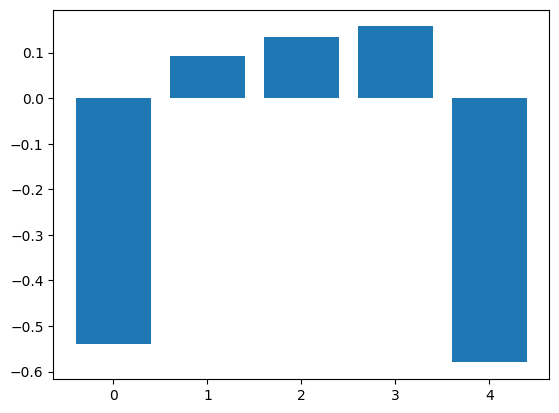

In [ ]:
plt.bar(range(num_hidden), model.rnn.weight_ih_l0.detach().squeeze());